# **決定木の実装例（その1）**

ここでは，第3章で整理した決定木の理論とアルゴリズムをデータ分析問題に適用してみます．分割基準や木の深さ，リーフノードの制約といった主要なハイパーパラメータが，モデルの振舞いにどのような影響を与えるのかも確認します．

## **分類問題（ペンギンの分類）**

ここでは，「Palmer Penguins」データセットを用いて，決定木による多クラス分類の具体例を示します．このデータセットは，パルマー諸島に生息する3種類のペンギン (Adelie, Chinstrap, Gentoo) について，くちばしの寸法やひれ足の長さ等の身体的特徴を，数値変数およびカテゴリ変数として整理したものです．特徴量の種類が混在しており，かつ分類対象も直感的に理解しやすいため，決定木がどのような基準で分割を行い，クラス判別を進めていくのかを観察する題材として適しています．

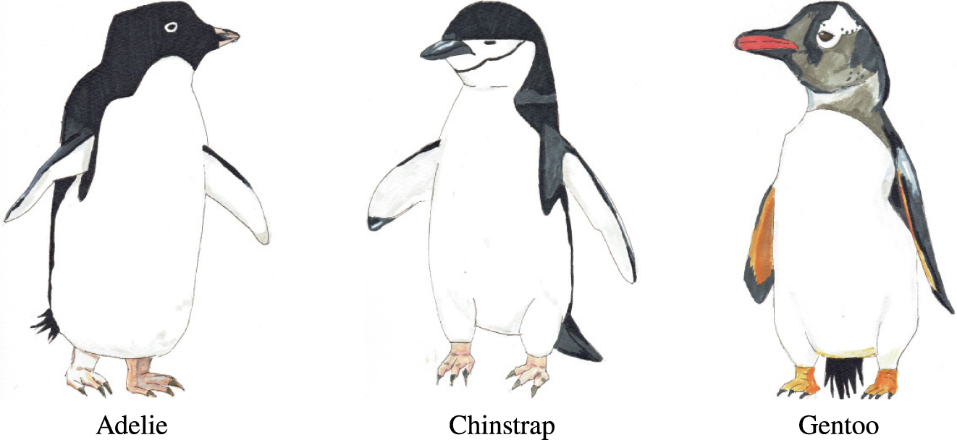

#### **■Step 0. ライブラリのインポート**

まず，必要なライブラリを一括してインポートします．

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

#### **■Step 1. データの準備**

分類木を構築するために，特徴量（入力変数）とターゲット（予測対象）を含むデータセットを用意し，解析に適した形へ前処理を行います．

**Step 1**①はデータの読み込みです．「Palmer Penguins」データセットは，可視化や統計解析で広く利用されている Python のライブラリ seaborn に標準で含まれており，追加のファイルを用意することなく簡単に読み込むことができます．データセットを取得し，内容を確認するための最小限のコード例を示します．

In [3]:
# データ読み込み
data = sns.load_dataset("penguins")
data.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


データセットには次の項目があります．

- species：ペンギンの種類で Adelie, Chinstrap, Gentoo の3種類

- island：データの個体が生息していた島

- bill_length_mm：くちばしの長さ（単位は mm）

- bill_depth_mm：くちばしの厚み（単位は mm）

- flipper_length_mm：ひれ足の長さ（単位は mm）

- body_mass_g：体重（単位は g）

- sex：雌雄

以下では，island，bill_length_mm，bill_depth_mm，flipper_length_mm，body_mass_g，sex の6変数を特徴量として用い，ペンギンの種類 species を予測する分類木を構築します．

**Step 1**②はデータの前処理です．元のデータセットは344個体分の観測値から構成されていますが，一部の変数に欠損値が含まれています．そこで，解析を単純化するため，**欠損値を含む行を削除**し，333個体分のデータを用います（dropna）．

決定木は，特徴量についてはカテゴリ変数を直接扱うことができます．ただし，実際の分析では，使用するライブラリの仕様に応じた前処理が必要になる場合があります．ここで用いる scikit-learn の DecisionTreeClassifier は，特徴量として数値変数のみを受け付けます．そのため，island（生息する島）やsex（雌雄）といったカテゴリ変数については，予め数値に変換したうえでモデルに入力します．厳密には，ワンホットエンコーディングを使って順序性のない符号化をすべきですが，ここでは簡易的に，island は Torgersen を 0，Dream を 1，Biscoe を 2とし，sex は Male を 0，Female を 1とするラベルエンコーディングを行います．一方，ターゲット変数であるペンギンの種類（species）については，DecisionTreeClassifier の仕様上，カテゴリ変数のまま扱うことが可能です．

続いて，モデルの性能評価のため，データを**トレーニングデータとテストデータに分割**します．ここでは，全体の70%（233個体）をトレーニングデータ，残りの30%（100個体）をテストデータとして用います．分割にあたっては，ペンギンの種類ごとの比率が両データで大きく偏らないよう，**層化**を行います．これにより，学習時と評価時でクラス分布の条件を揃えたまま，モデルの汎化性能を確認することができます．

以上を踏まえ，ここまでのデータ準備および前処理をまとめたコードを示します．

In [4]:
# ターゲットのラベルを確認
target_name = 'species'
print(f'Target labels: {data[target_name].unique()}')
feature_names = data.columns.drop(target_name)
print(f'Feature names: {feature_names.tolist()}')
class_names = data[target_name].unique().tolist()
print(f'Class names: {class_names}')

# 欠損値のあるデータを削除
print("Original data shape:", data.shape)
data = data.dropna()
print("-> After dropna shape:", data.shape)

# カテゴリ変数（特徴量）をラベルエンコーディング
category_mappings = {
    'island': {'Torgersen': 0, 'Dream': 1, 'Biscoe': 2},
    'sex': {'Male': 0, 'Female': 1}
}
data = data.replace(category_mappings)

# 特徴量とターゲットに分ける（ターゲットはカテゴリのまま）
X = data.drop(columns=target_name)
y = data[target_name]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# トレーニングデータとテストデータに分ける（層化サンプリング）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Training data shape:", X_train.shape, y_train.shape)
print("Test data shape:", X_test.shape, y_test.shape)

Target labels: ['Adelie' 'Chinstrap' 'Gentoo']
Feature names: ['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
Class names: ['Adelie', 'Chinstrap', 'Gentoo']
Original data shape: (344, 7)
-> After dropna shape: (333, 7)
Features shape: (333, 6)
Target shape: (333,)
Training data shape: (233, 6) (233,)
Test data shape: (100, 6) (100,)


/tmp/ipykernel_2459/178327602.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace(category_mappings)


**Step 1**③はデータの理解です．データを理解するためにデータの基本情報を取得します．そして，ターゲットと各特徴量の相関，特徴量間の相関，各特徴量の分布をまとめて表示できるペアプロットを作成します．なお，カテゴリ変数をペアプロットにしても直線上にデータ点が並んでしまい分布が見えにくいので，数値変数だけ抜き出してペアプロットを作成します．

次に，データを理解するためにデータの基本情報を取得します．

また，ターゲットと各特徴量の相関，特徴量間の相関，各特徴量の分布をまとめて表示できるペアプロットを作成します．なお，カテゴリー変数をペアプロットにしても直線上にデータ点が並んでしまい分布が見えにくいので，数値変数だけ抜き出してペアプロットを作成します．

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,233.000000,233.000000,233.000000,233.000000,233.000000,233.000000
mean,1.309013,43.998283,17.254936,201.390558,4230.901288,0.467811
std,0.730349,5.527057,1.983419,13.945006,804.523206,0.500037
min,0.000000,33.500000,13.100000,172.000000,2900.000000,0.000000
25%,1.000000,39.000000,15.700000,190.000000,3600.000000,0.000000
50%,1.000000,44.500000,17.500000,198.000000,4050.000000,0.000000
75%,2.000000,49.000000,18.800000,213.000000,4750.000000,1.000000
max,2.000000,59.600000,21.200000,231.000000,6300.000000,1.000000


,species
count,233
unique,3
top,Adelie
freq,102


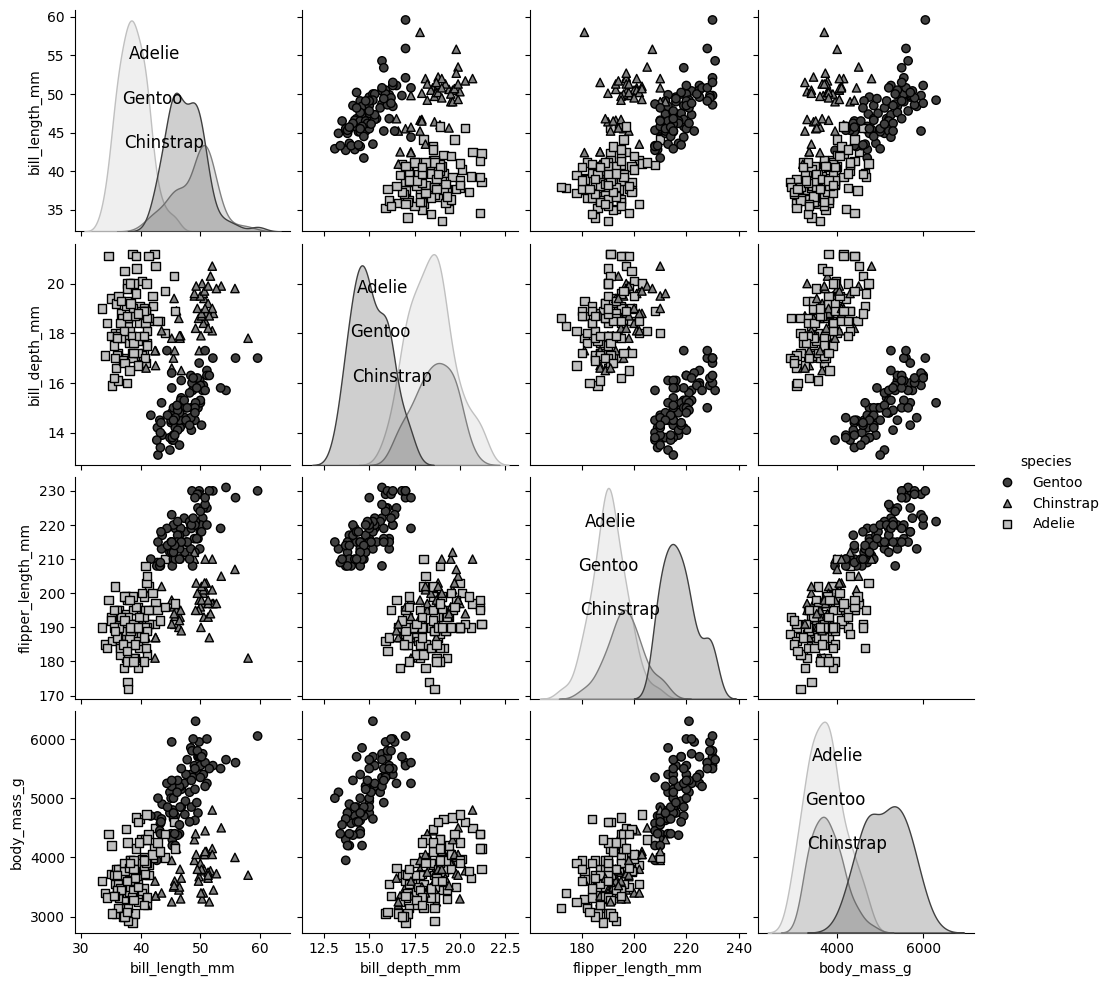

ペアプロットが 'penguin_pairplot.svg' に保存されました．


In [5]:
# データの概要
display(X_train.describe())
display(y_train.describe())
# 数値型列のうち，ラベルエンコーディングされた列を除外
excluded_columns = ['island', 'sex']
numeric_columns = [col for col in X_train.columns if col not in excluded_columns]
# 数値列のみのデータフレームを作成
data_num = pd.DataFrame(X_train, columns=X.columns)[numeric_columns]
data_num = data_num.assign(species=y_train)  # ターゲット列を追加
# ヒストグラムにカテゴリ名を表示する関数
def add_species_label(x, **kws):
    ax = plt.gca()
    species_name = kws.get('label', '')
    # 表示位置をカテゴリごとに調整
    offsets = {"Adelie": (0.49, 0.8), "Chinstrap": (0.6, 0.4), "Gentoo": (0.5, 0.6)}
    offset = offsets.get(species_name, (1, 0.5))  # デフォルト位置 (中央)
    # ラベルを配置
    ax.annotate(species_name, xy=offset, xycoords=ax.transAxes, ha='right', va='center', fontsize=12, color='black', zorder=2)
# ペアプロットの作成
pairplot = sns.pairplot(
    data_num,
    hue="species",
    palette="gray",
    markers=["o", "^", "s"],  # マーカー: ●, △, ■
    plot_kws={'edgecolor': 'black', 'linewidth': 1},
)
# ヒストグラムにカテゴリラベルを追加
pairplot.map_diag(add_species_label)
# SVG形式で保存
output_path = 'penguin_pairplot.svg'
pairplot.savefig(output_path, format='svg')
# 表示
plt.show()
print(f"ペアプロットが '{output_path}' に保存されました．")

表は，前処理後のデータに対する基本的な統計量を示したもので，上は特徴量（説明変数）に関する統計量，下はターゲット変数（species）に関する情報です．

上の表では，各特徴量について次の統計量を示しています．

- count：欠損値を除いた有効なデータ数

- mean：平均値

- std：標準偏差

- min / max：最小値および最大値

- 25%，50%，75%：四分位点（中央値を含む）

ここで，island や sex はラベルエンコーディングにより整数値として表現されているため，平均値や分位点は「数値としての集約結果」であり，カテゴリの意味的な大小を表すものではありません．一方で，bill_length_mm や body_mass_g 等の連続値変数については，分布の広がりや代表値を確認する目的で解釈できます．

また，下の表は，ターゲット変数 species の分布を示しています．count はデータ数，unique はクラス数，top は最も出現頻度の高いクラス，freq はその出現回数を表します．この結果から，本データセットは3クラス分類問題であり，クラス間の出現頻度に一定の偏りがあることが確認できます．

ペアプロットからは3つのクラスの分布が読み取れるので，分類タスクの難易度等を推測できます．

#### **■Step 2. 分類木の初期設定**

分類木の構築にあたり，まずモデルの初期設定をします．今回は scikit-learn の DecisionTreeClassifier ライブラリを使います．このライブラリは CART のアルゴリズムを実装したものなので，ノード分割にデフォルトのジニ不純度を使うことにします．また，モデルの複雑さが分類結果に与える影響を確認するため，ハイパーパラメータとして最大深度を引数として渡し，実行時にはその値を段階的に増やしていきます．さらに，過学習を防ぐために，ノードの最小サンプル数を10と設定します．

In [6]:
# 分類木モデルの初期設定
def model_init(max_depth):
    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=max_depth,
        min_samples_leaf=10,
        random_state=42
    )
    return model

#### **■Step 3. 子ノードの生成**

決定木では，各ノードにおいて，予め定めた分割基準に従い，最も適切な特徴量と分割条件を選択します．ここでは，分割基準としてジニ不純度を用い，ルートノードからどのように子ノードが生成されていくかを確認します．

まず，トレーニングデータ全体を決定木の起点となるルートノードに配置します．このデータをもとに，特徴量による分割を繰り返しながら，種別を識別する決定木を構築していきます．

ここで，ジニ不純度の定義を復習しておきます．$n$ 個のデータが $M$ 個のクラスに分かれており，それぞれのクラスに属するデータ数を $n_{1},n_{2},\dots,n_{M}$ とします．各クラスの相対度数 $p_{i} = n_{i}/n$ を用いて，ジニ不純度 $G$ は次式で定義されます．

$$G = 1 - \sum_{i = 1}^{M}p_{i}^{2} \tag{1}$$

次に，式$(1)$を用いて，ルートノードにおけるジニ不純度 $G_{0}$ を計算します．ここで用いるトレーニングデータでは，ルートノードに含まれる233個体の内訳は，Adelie が102個体，Chinstrap が48個体，Gentoo が83個体です．したがって，$G_{0}$ は次のようになります．

$$G_{0} = 1 - \left( \frac{102}{233} \right)^{2} - \left( \frac{48}{233} \right)^{2} - \left( \frac{83}{233} \right)^{2} = 0.639$$

決定木では，このルートノードを起点として，子ノードの不純度ができるだけ小さくなるような特徴量と分割閾値の組み合わせを探索します．CART アルゴリズムでは，分割後の重み付きジニ不純度 ${\overset{ˉ}{G}}_{1}^{(w)}$ が最小となる分割を選択します．これは言い換えると，「**分割によってクラスの混ざり具合が最も減少する分割**」を選ぶということです．

**Step 3**①はルートノードの分割です．次のコードでは，最大深度を1に制限した決定木を学習させることで，ルートノードにおける最初の分割のみを実行し，その結果を可視化しています．この操作により，CART アルゴリズムが「どの特徴量を，どの閾値で分割するのが最も効果的か」をどのように判断しているかを直接確認できます．

Training score: 0.7854077253218884
Test score: 0.78
Decision tree saved as SVG: penguin_decision_tree_depth1.svg


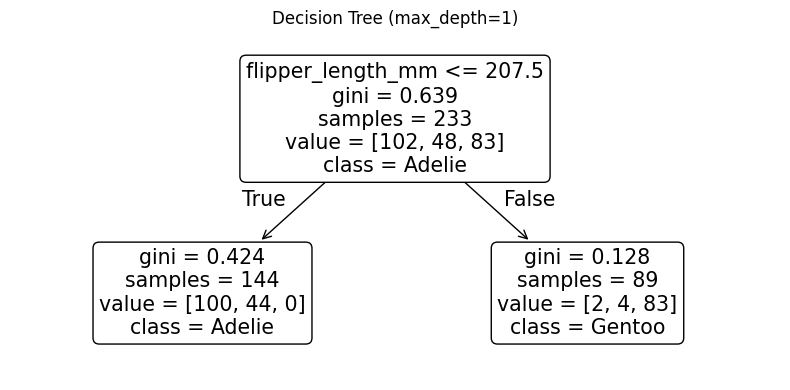

In [7]:
max_depth = 1
model = model_init(max_depth=max_depth)
model.fit(X_train, y_train)

# 学習データとテストデータでの精度評価
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_score = accuracy_score(y_train, train_pred)
test_score = accuracy_score(y_test, test_pred)

print("Training score:", train_score)
print("Test score:", test_score)
plt.figure(figsize=(8, 4))
plot_tree(
    model,
    feature_names=feature_names,
    class_names=class_names,
    filled=False,
    rounded=True
)

plt.title(f"Decision Tree (max_depth={max_depth})")
plt.tight_layout()

svg_path = f"penguin_decision_tree_depth{max_depth}.svg"
plt.savefig(svg_path)
print("Decision tree saved as SVG:", svg_path)
plt.show()

ルート分割の結果，ルートノードからの子ノード作成では，特徴量として flipper_length_mm，閾値は 207.5 mm が選ばれ，閾値 207.5 mm 以下かどうか（左が True，右が False）で2つの子ノードが生成されています．実際にジニ不純度を計算してみましょう．

True 側すなわち左側の子ノードのジニ不純度 $G_{11}$（添え字は，深さ1の左から1番目のノードの意味．以下同様）は，

$$G_{11} = 1 - \left\{ \left( \frac{100}{144} \right)^{2} + \left( \frac{44}{144} \right)^{2} + \left( \frac{0}{144} \right)^{2} \right\} = 0.424$$

False 側すなわち右側の子ノードのジニ不純度 $G_{12}$ は，

$$G_{12} = 1 - \left\{ \left( \frac{2}{89} \right)^{2} + \left( \frac{4}{89} \right)^{2} + \left( \frac{83}{89} \right)^{2} \right\} = 0.128$$

と計算されます．これらの加重平均，すなわち各ノードの個体数の全個体数に対する比率（相対度数）を各ジニ不純度にかけて和をとったものを ${\overline{G}}_{1}$ とすると，

$${\overline{G}}_{1} = \frac{144}{233}G_{11} + \frac{89}{233}G_{12} = \frac{144}{233}0.424 + \frac{89}{233}0.128 = 0.311$$

となり，分割前のルートノードのジニ不純度 $G_{0} = 0.639$ と比べて大きく低下しています．

$$G_{0} - {\overset{ˉ}{G}}_{1} = 0.639 - 0.311 = 0.328$$

**この分割によってクラスの混在度が大幅に減少した**ことが確認できます．この結果は，flipper_length_mm という単一の特徴量によって，Gentoo をほぼ単独のグループとして切り出し，残りの2種類を別の側にまとめるという，直感的にも理解しやすい分類が実現されていることを意味します．CART アルゴリズムは，このように「不純度の低下が最大となる分割」を逐次選択することで，分類木を成長させていきます．

**Step 3**②は，深さ2の分割です．決定木の成長をさらに確認するため，最大深度を，max_depth=2 と設定します．これにより，ルート分割に続いて，各子ノードに対する次の分割が許可され，その結果が次のコードを実行することで可視化されます．この操作は，「ルート分割によってある程度クラスが分離された後，残った混在をどの特徴量で解消するか」を CART アルゴリズムがどのように判断するかを確認するためのものです．

次のコードは，1行目以外は**Step 3**①と同じです．

Training score: 0.944206008583691
Test score: 0.93
Decision tree saved as SVG: penguin_decision_tree_depth2.svg


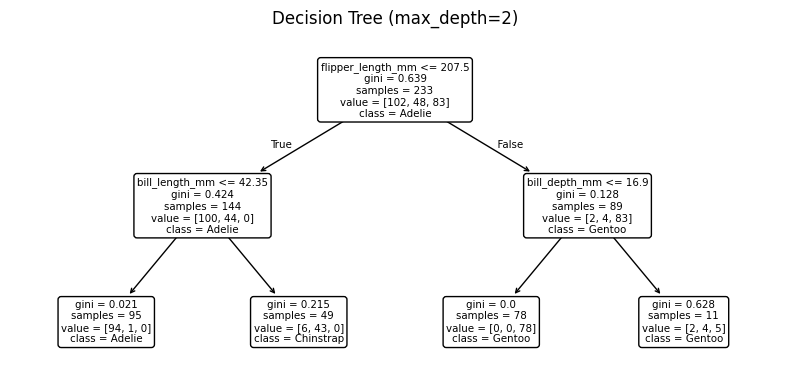

In [8]:
max_depth = 2
model = model_init(max_depth=max_depth)
model.fit(X_train, y_train)

# 学習データとテストデータでの精度評価
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_score = accuracy_score(y_train, train_pred)
test_score = accuracy_score(y_test, test_pred)

print("Training score:", train_score)
print("Test score:", test_score)
plt.figure(figsize=(8, 4))
plot_tree(
    model,
    feature_names=feature_names,
    class_names=class_names,
    filled=False,
    rounded=True
)

plt.title(f"Decision Tree (max_depth={max_depth})")
plt.tight_layout()

svg_path = f"penguin_decision_tree_depth{max_depth}.svg"
plt.savefig(svg_path)
print("Decision tree saved as SVG:", svg_path)
plt.show()

ルート分割によって生じた左側の子ノードから，特徴量 bill_length_mm，閾値 42.35 mm で新たな子ノードが生成されました．True 側すなわち左側の子ノードのジニ不純度 $G_{21}$ ，False 側すなわち右側の子ノードのジニ不純度 $G_{22}$ はそれぞれ次のように計算されます．

$$G_{21} = 1 - \left\{ \left( \frac{94}{95} \right)^{2} + \left( \frac{1}{95} \right)^{2} + \left( \frac{0}{95} \right)^{2} \right\} = 0.021$$

$$G_{22} = 1 - \left\{ \left( \frac{6}{49} \right)^{2} + \left( \frac{43}{49} \right)^{2} + \left( \frac{0}{49} \right)^{2} \right\} = 0.215$$

また，$G_{21}$ ，$G_{22}$ の加重平均 ${\overline{G}}_{2w1}$ は次のように計算されます．

$${\overline{G}}_{2w1} = \frac{95}{144}G_{21} + \frac{49}{144}G_{22} = \frac{95}{144}0.021 + \frac{49}{144}0.215 = 0.087$$

${\overline{G}}_{2w1}$ と親ノードのジニ不純度 $G_{11}$ との差は，

$$G_{11} - {\overline{G}}_{2w1} = 0.337$$

となり，この分割によって不純度が大きく低下していることが確認できます．すなわち，深さ2の分割では，flipper_length_mm **でGentooを切り分けた後，** bill_length_mm **によって Adelie と Chinstrap をほぼ分離する**という，データ構造に即した階層的な分類が実現されています．このように，決定木は各段階で「現在のノードに残っている混在を最も減らす分割」を選択しながら，段階的にクラスを分離していきます．深さを増やすとは，単に分割回数を増やすことではなく，**より局所的な構造に基づいて判断を細分化していくこと**を意味します．

#### **■Step 4. 終了条件を満たすまでの再帰的な木の成長**

決定木の構築では，各ノードで分割を行うたびに，予め定めた終了条件が満たされているかを確認します．終了条件が満たされていない場合は**Step 3**に戻り，分割基準の選択とデータの分割を続けます．一方，いずれかの終了条件が満たされた時点で，そのノードはリーフノードとして確定し，それ以上の分割は行われません．

代表的な終了条件には，「決定木の深さが指定した上限に達した」「ノードに含まれるサンプル数が一定以下になった」といったものがあります．これらは，モデルの複雑さを制御し，過学習を防ぐために導入されます．

**Step 2**のコードでは，リーフノードに含める最小サンプル数を min_samples_leaf=10 と設定しています．これは，ごく少数の個体に基づいて分割が行われることを防ぎ，偶然のばらつきに過度に適合したモデルになるのを抑えるためです．言い換えると，この条件は「各判断には最低限の根拠となるデータ量を要求する」という制約を与えており，決定木の汎化性能を保つ役割を果たします．

また，前回のループより精度が向上しなかった場合（改善が見られない場合）や達成したい正解率の閾値に達した場合は，早期打ち切りとします．次のコードでは，target_accuracy=0.95 と設定してあり，必要以上に精度を求めないよう制約を与えて汎化性能を保とうとしています．

In [10]:
# スコアを保存するリスト
evaluation_metrics = []
training_accuracies = []
test_accuracies = []

# max_depth の範囲を広めに設定（終了条件があるため）
max_depth_range = range(1, 21)
min_samples_leaf = 10

# 終了条件のための設定
target_accuracy = 0.95  # 達成したい正解率の閾値
best_test_accuracy = 0.0

for max_depth in max_depth_range:
    # 決定木の設定
    tree = DecisionTreeClassifier(criterion='gini', max_depth=max_depth,
                                 min_samples_leaf=min_samples_leaf,
 random_state=42)

    # 決定木を構築
    tree.fit(X_train, y_train)

    # トレーニングデータとテストデータの予測
    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    # Accuracy の計算
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    # 精度評価指標を計算
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, test_pred, average='weighted', zero_division=0
    )

    evaluation_metrics.append({
        'max_depth': max_depth,
        'accuracy': test_accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    })

    # Accuracy を保存
    training_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    # 混同行列の計算と保存
    unique_labels = y.unique()
    cm = confusion_matrix(y_test, test_pred, labels=unique_labels)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
    disp.plot(cmap="Greys", ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix (Max Depth={max_depth})")
    plt.tight_layout()
    confusion_matrix_path = f"confusion_matrix_depth{max_depth}.svg"
    plt.savefig(confusion_matrix_path, format="svg")
    plt.close(fig)
    print(f"Max Depth {max_depth}: Accuracy = {test_accuracy:.4f}")
    print(f"Confusion matrix saved: {confusion_matrix_path}")

    # 特徴量の重要度を棒グラフで表示
    feature_importances = tree.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(8, 6))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='gray')
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Feature Importance (Max Depth={max_depth})")
    feature_importance_path = f"feature_importance_depth{max_depth}.svg"
    plt.tight_layout()
    plt.savefig(feature_importance_path, format="svg")
    plt.close()
    print(f"Feature importance saved: {feature_importance_path}")

    # --- 終了条件の判定 ---
    # 1. 目標とする正解率に達した場合
    if test_accuracy >= target_accuracy:
        print(f"Target accuracy ({target_accuracy}) reached. Stopping loop.")
        break

    # 2. 前回のループより精度が向上しなかった場合（改善が見られない場合）
    if test_accuracy <= best_test_accuracy:
        print(f"No improvement in accuracy. Stopping loop at depth {max_depth}.")
        break

    # 最高精度の更新
    best_test_accuracy = test_accuracy
    print("-" * 30)

Max Depth 1: Accuracy = 0.7800
Confusion matrix saved: confusion_matrix_depth1.svg
Feature importance saved: feature_importance_depth1.svg
------------------------------
Max Depth 2: Accuracy = 0.9300
Confusion matrix saved: confusion_matrix_depth2.svg
Feature importance saved: feature_importance_depth2.svg
------------------------------
Max Depth 3: Accuracy = 0.9400
Confusion matrix saved: confusion_matrix_depth3.svg
Feature importance saved: feature_importance_depth3.svg
------------------------------
Max Depth 4: Accuracy = 0.9400
Confusion matrix saved: confusion_matrix_depth4.svg
Feature importance saved: feature_importance_depth4.svg
No improvement in accuracy. Stopping loop at depth 4.


#### **■Step 5. 分類木の評価**

次に，構築した分類木がどの程度適切にデータを分類できているかを評価します．ここでは，決定木の最大深さ max_depth を変化させながら，モデルの性能指標がどのように変化するかを確認します．

具体的には，正解率（accuracy）を用いて，モデルの深さに伴う性能の推移を折れ線グラフとして可視化します．これにより，木を深くすることで性能が向上するのか，あるいは頭打ちや低下が生じるのかを把握できます．さらに，precision ，recall ，f1-score といった指標を併せて算出し，クラスごとの分類特性を表として整理します．混同行列も作成し，どのクラス間で誤分類が生じやすいかを確認します．これらの評価は，「決定木をどこまで成長させるのが妥当か」，すなわち**モデルの表現力と過学習のバランス**を検討するための基礎情報を与えます．

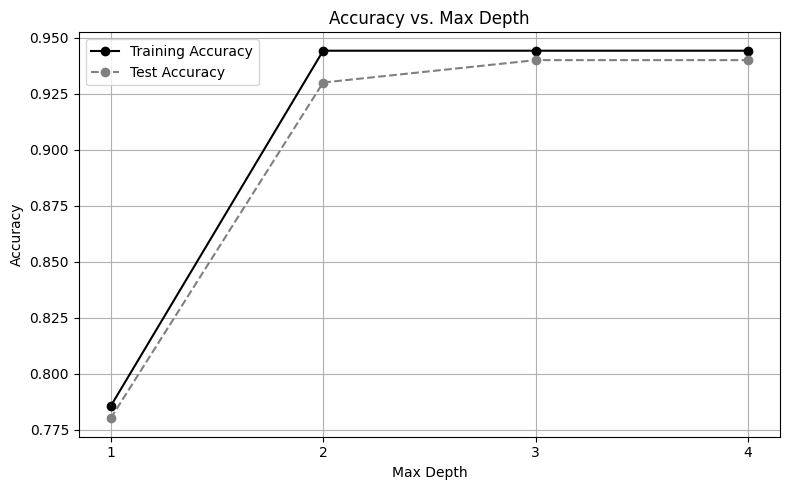

Accuracy plot saved as SVG: accuracy_vs_max_depth.svg
Evaluation metrics saved as Excel: evaluation_metrics.xlsx
Evaluation metrics by Max Depth:
   max_depth  accuracy  precision  recall  f1_score
0          1      0.78   0.653333    0.78  0.701714
1          2      0.93   0.948148    0.93  0.933421
2          3      0.94   0.941739    0.94  0.940381
3          4      0.94   0.941739    0.94  0.940381


In [11]:
# --- グラフの描画 ---
# ループが途中で終了した場合に備え，実際に計算されたデータの数に合わせてx軸を調整します
actual_depths = [m['max_depth'] for m in evaluation_metrics]

accuracy_plot_path = "accuracy_vs_max_depth.svg"
plt.figure(figsize=(8, 5))
# max_depth_range の代わりに actual_depths を使用します
plt.plot(actual_depths, training_accuracies, label="Training Accuracy",
color="black", marker="o")
plt.plot(actual_depths, test_accuracies, label="Test Accuracy",
color="gray", linestyle="--", marker="o")

plt.title("Accuracy vs. Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
# x軸の目盛りも実際の深さに合わせます
plt.xticks(actual_depths)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(accuracy_plot_path, format="svg")
plt.show()
print(f"Accuracy plot saved as SVG: {accuracy_plot_path}")

# --- 評価指標の保存 ---
# 評価指標をDataFrameに変換
metrics_df = pd.DataFrame(evaluation_metrics)

# xlsxファイルとして保存
metrics_path = "evaluation_metrics.xlsx"
metrics_df.to_excel(metrics_path, index=False)
print(f"Evaluation metrics saved as Excel: {metrics_path}")

# 表をコンソールに表示
print("Evaluation metrics by Max Depth:")
print(metrics_df)

以下，このコードの実行結果について解説します．

##### **分類木の評価結果とモデル選択の意味**

ここまでに構築した分類木は，学習に用いたデータだけでなく，未知のペンギン個体に対しても種別を予測するためのモデルとして運用されます．そのため，学習性能ではなく，**テストデータに対する汎化性能**を基準として，モデルの複雑さを評価する必要があります．

出力中の折れ線グラフは，決定木の最大深度を1から4まで変化させたときの，トレーニングデータおよびテストデータに対する正解率の推移を示したものです．この図から，深さ1では分類能力が不十分である一方，深さを2にすると性能が大きく向上し，**深さ3でテスト正解率がほぼ最大に達している**ことが確認できます．さらに，それ以降，深さを増やしてもテスト正解率は改善せず，モデルの表現力が性能向上に寄与しなくなっていることがわかります．

また，出力された表から，accuracy ，precision ，recall ，f1-score も同様の傾向を示しており，max_depth=3 が，性能とモデルの単純さのバランスがとれた設定であると判断できます．このように，**評価指標の推移を見る操作は，「どこで木の成長を止めるべきか」を決めるための判断材料**を与えています．

##### **混同行列が示す誤分類構造**

出力中の混同行列は，モデルが「どのクラスを，どのクラスと混同しやすいか」を可視化したものです．深さ1の場合，Gentoo は比較的正確に分類されている一方，Adelie と Chinstrap はほぼ区別されていません．これは，最初の分割が主に Gentoo を他の2種から切り分ける役割を果たしていることに対応しています．

深さを2，3と増やすにつれて，Adelie と Chinstrap の誤分類が減少し，混同行列の対角成分が強調されていきます．一方で，深さ3から4では混同行列の構造がほぼ変化しておらず，**それ以上の分割が分類結果に新たな情報を与えていない**ことが読み取れます．

##### **特徴量重要度が示しているもの**

出力中の棒グラフは，max_depth=4 の決定木における特徴量重要度を示しています．特徴量重要度とは，各特徴量が分割に用いられた際に，**どれだけジニ不純度の低下に寄与したかを，全ノードにわたって加算・正規化した量**です．すなわち，「何回使われたか」ではなく，「どれだけ分類の不確実性を減らしたか」を示した指標です．

この結果から，flipper_length_mm と bill_length_mm が，分類性能の向上に大きく貢献していることがわかります．実際，**Step 3**②のコードを実行して出力された決定木の構造を確認すると，これらの特徴量による分割が上位ノードで用いられており，多数のサンプルに対して不純度を大きく低下させています．